# WK5: Real EMPCA Evaluation + Visualization (Rigorous Split Protocol)

This notebook combines:
- **real-data model evaluation flow** from `wk4/evaluate_EMPCA_6models_REIM_ridge.ipynb`
- **plot/table style** from `wk4/reim_visualization_samples.ipynb`

Rigor upgrades in this copy:
- split into **train / validation / test** per seed
- tune REIM hyperparameters (`k`, `alpha`) on **validation only**
- report final sigma/FWHM on untouched **test**
- repeat over multiple seeds and plot **mean ± 1σ**


In [1]:
import re
import gc
import sys
import pickle
from pathlib import Path

import numpy as np
import h5py
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def _repo_root():
    here = Path.cwd().resolve()
    cands = [here, here.parent, here.parent.parent]
    for c in cands:
        if (c / 'wk4').exists() and (c / 'reusable').exists():
            return c
        if (c / 'PCA_dev' / 'wk4').exists() and (c / 'PCA_dev' / 'reusable').exists():
            return c / 'PCA_dev'
    raise RuntimeError('Run this notebook from DELight_mtr, PCA_dev, or PCA_dev/wk5 directory.')


repo = _repo_root()
print('repo =', repo)

sys.path.insert(0, str(repo / 'reusable'))
from empca_TCY_optimized import ti_rfft

HAVE_OF_NATIVE = False
try:
    from OptimumFilter import OptimumFilter as OptimumFilterNative
    HAVE_OF_NATIVE = True
    print('OptimumFilter native class import: OK')
except Exception as exc:
    print('OptimumFilter native class import failed:', exc)

# OF backend choice:
# - 'safe': robust fallback implementation (default; avoids native ctor crash in this runtime)
# - 'native': use reusable/OptimumFilter.py class directly
OF_BACKEND = 'safe'

FIG_DIR = repo / 'wk5' / 'figures' / 'reim_viz_real_models_rigorous'
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('figure dir =', FIG_DIR)

MODELS_DIR = repo / 'wk4' / 'models'
FS = 3906250.0

TRAIN_FRAC = 0.50
VAL_FRAC = 0.20
TEST_FRAC = 0.30
SEEDS = [0, 1, 2, 3, 4]

# dataset usage controls
USE_FULL_DATASET = True   # if True, expand baked model paths to all matching batches in the same folder
MAX_BATCHES = None        # set integer to cap number of batches

MODEL_FILES = [
    'PSD_run1_sum_mmc.pkl',
    'SNR2_run1_sum_mmc.pkl',
    'PSD_run1_sum_white.pkl',
    'SNR2_run1_sum_white.pkl',
    'PSD_run1_sum_pink.pkl',
    'SNR2_run1_sum_pink.pkl',
]

QP_TEMPLATE_CANDIDATES = [
    repo / 'reusable' / 'template' / 'qp_template.npy',
    repo / 'reusable' / 'template' / 'QP_template.npy',
    repo.parent / 'trigger_study' / 'archive' / 'wk9' / 'preliminary' / 'sum_qp_template_1800.npy',
]

NOISE_PSD_PATHS = {
    'mmc': Path('/ceph/dwong/delight/noise_psd_xray.npy'),
    'white': repo / 'reusable' / 'weight' / 'noise_psd_white.npy',
    'pink': repo / 'reusable' / 'weight' / 'noise_psd_pink.npy',
}

METHOD_REIM = 'k-PC Ridge (Re/Im)'
METHOD_EUCLID2 = 'Euclid-2 + Linear'
METHOD_OF = 'OF'
METHOD_OF_SHIFT = 'OF+shift'
METHOD_ORDER = [METHOD_OF, METHOD_OF_SHIFT, METHOD_REIM, METHOD_EUCLID2]

COLORS = {
    METHOD_OF: '#D1495B',
    METHOD_OF_SHIFT: '#EDAE49',
    METHOD_REIM: '#00798C',
    METHOD_EUCLID2: '#66A182',
    'PSD': '#2A9D8F',
    'SNR2': '#1D3557',
}

plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

print('split config:', {'train': TRAIN_FRAC, 'val': VAL_FRAC, 'test': TEST_FRAC, 'seeds': SEEDS})
print('dataset config:', {'use_full_dataset': USE_FULL_DATASET, 'max_batches': MAX_BATCHES})
print('OF backend:', OF_BACKEND)


repo = /home/dwong/DELight_mtr/PCA_dev
OptimumFilter native class import: OK
figure dir = /home/dwong/DELight_mtr/PCA_dev/wk5/figures/reim_viz_real_models_rigorous
split config: {'train': 0.5, 'val': 0.2, 'test': 0.3, 'seeds': [0, 1, 2, 3, 4]}
dataset config: {'use_full_dataset': True, 'max_batches': None}
OF backend: safe


In [2]:
def resolve_local_path(path_like):
    if path_like is None:
        return None
    p = Path(path_like)
    if p.exists():
        return p

    s = str(p)
    marker = 'PCA_dev/'
    if marker in s:
        suffix = s.split(marker, 1)[1]
        cand = repo / suffix
        if cand.exists():
            return cand
    return p


def choose_qp_template_path():
    for p in QP_TEMPLATE_CANDIDATES:
        if p.exists():
            return p
    return None


def preflight_checks():
    missing = []
    info = []

    artifacts = {}
    for name in MODEL_FILES:
        p = MODELS_DIR / name
        ok = p.exists()
        info.append(('model', str(p), ok))
        if not ok:
            missing.append(str(p))
            continue
        with open(p, 'rb') as f:
            artifacts[name] = pickle.load(f)

    data_paths = set()
    for name, art in artifacts.items():
        psd_path = resolve_local_path(art.get('psd_path'))
        snr_path = resolve_local_path(art.get('snr2_weight_path'))

        if psd_path is not None:
            ok = psd_path.exists()
            info.append(('psd', f'{name}: {psd_path}', ok))
            if not ok:
                missing.append(str(psd_path))

        if snr_path is not None:
            ok = snr_path.exists()
            info.append(('snr2', f'{name}: {snr_path}', ok))
            if not ok:
                missing.append(str(snr_path))

        for dp in art.get('dataset_paths', [])[:1]:
            data_paths.add(str(dp))

    for dp in sorted(data_paths):
        p = Path(dp)
        ok = p.exists()
        info.append(('data', str(p), ok))
        if not ok:
            missing.append(str(p))

    qp_path = choose_qp_template_path()
    if qp_path is None:
        info.append(('template', 'qp template (all candidates)', False))
        missing.append('qp template: none of candidates found')
    else:
        info.append(('template', str(qp_path), True))

    print('--- preflight checks ---')
    for kind, path, ok in info:
        tag = 'OK' if ok else 'MISSING'
        print(f'[{tag}] {kind:<8} {path}')

    print('missing_count =', len(set(missing)))
    return artifacts, sorted(set(missing)), qp_path


artifacts, missing_assets, qp_template_path = preflight_checks()
print('loaded_artifacts =', len(artifacts))
print('qp_template_path =', qp_template_path)


--- preflight checks ---
[OK] model    /home/dwong/DELight_mtr/PCA_dev/wk4/models/PSD_run1_sum_mmc.pkl
[OK] model    /home/dwong/DELight_mtr/PCA_dev/wk4/models/SNR2_run1_sum_mmc.pkl
[OK] model    /home/dwong/DELight_mtr/PCA_dev/wk4/models/PSD_run1_sum_white.pkl
[OK] model    /home/dwong/DELight_mtr/PCA_dev/wk4/models/SNR2_run1_sum_white.pkl
[OK] model    /home/dwong/DELight_mtr/PCA_dev/wk4/models/PSD_run1_sum_pink.pkl
[OK] model    /home/dwong/DELight_mtr/PCA_dev/wk4/models/SNR2_run1_sum_pink.pkl
[OK] psd      PSD_run1_sum_mmc.pkl: /ceph/dwong/delight/noise_psd_xray.npy
[OK] snr2     SNR2_run1_sum_mmc.pkl: /home/dwong/DELight_mtr/PCA_dev/reusable/weight/qp_snr2_weight_MMC.npy
[OK] psd      PSD_run1_sum_white.pkl: /home/dwong/DELight_mtr/PCA_dev/reusable/weight/noise_psd_white.npy
[OK] snr2     SNR2_run1_sum_white.pkl: /home/dwong/DELight_mtr/PCA_dev/reusable/weight/qp_snr2_weight_white.npy
[OK] psd      PSD_run1_sum_pink.pkl: /home/dwong/DELight_mtr/PCA_dev/reusable/weight/noise_psd_pi

In [3]:
def baseline_correct_per_trace(X_time, pretrigger=4000, method='mean'):
    X_time = np.asarray(X_time, dtype=np.float64)
    pre = X_time[:, :pretrigger]
    if method == 'mean':
        baseline = np.mean(pre, axis=1)
    elif method == 'median':
        baseline = np.median(pre, axis=1)
    else:
        raise ValueError("method must be 'mean' or 'median'")
    return X_time - baseline[:, None], baseline


def to_shift_invariant_spectrum(X_time):
    X_tilde = ti_rfft(X_time)
    if X_tilde.ndim != 2:
        raise RuntimeError('Unexpected output shape from ti_rfft')
    return X_tilde


def solve_linear_system(A, b, eps=1e-12):
    # Small dense solver (Gauss-Jordan with pivoting) to avoid np/scipy linalg OpenMP crashes.
    A = np.asarray(A, dtype=np.complex128).copy()
    b = np.asarray(b, dtype=np.complex128)

    vec_rhs = (b.ndim == 1)
    if vec_rhs:
        b = b[:, None]

    n = A.shape[0]
    if A.ndim != 2 or A.shape[1] != n:
        raise ValueError('A must be square')
    if b.shape[0] != n:
        raise ValueError('b has incompatible leading dimension')

    aug = np.concatenate([A, b.copy()], axis=1)

    for i in range(n):
        piv = i + int(np.argmax(np.abs(aug[i:, i])))
        if np.abs(aug[piv, i]) <= eps:
            raise ValueError('Singular matrix in solve_linear_system')
        if piv != i:
            aug[[i, piv]] = aug[[piv, i]]

        aug[i, i:] = aug[i, i:] / aug[i, i]
        for r in range(n):
            if r == i:
                continue
            fac = aug[r, i]
            if fac != 0:
                aug[r, i:] = aug[r, i:] - fac * aug[i, i:]

    x = aug[:, n:]
    x = np.real_if_close(x, tol=1e5)
    if vec_rhs:
        return x[:, 0]
    return x


def project_coefficients(X_feat, eigvec, metric_weight):
    Phi = eigvec.T
    w = np.asarray(metric_weight, dtype=np.float64)

    Xw = X_feat * w[None, :]
    n_obs = Xw.shape[0]
    n_comp = Phi.shape[1]

    # A_ij = sum_f conj(Phi_fi) * w_f * Phi_fj
    A = np.empty((n_comp, n_comp), dtype=np.complex128)
    for i in range(n_comp):
        pi = np.conjugate(Phi[:, i])
        for j in range(n_comp):
            A[i, j] = np.sum(pi * (Phi[:, j] * w))

    # rhs_oj = sum_f Xw_of * conj(Phi_fj)
    rhs = np.empty((n_obs, n_comp), dtype=np.complex128)
    for j in range(n_comp):
        rhs[:, j] = np.sum(Xw * np.conjugate(Phi[:, j])[None, :], axis=1)

    coeff_t = solve_linear_system(A, rhs.T)
    coeff = coeff_t.T
    return coeff


def resolution_from_truth(y_est, y_true):
    resid = np.asarray(y_true) - np.asarray(y_est)
    sigma = np.std(resid, ddof=1)
    return float(sigma), float(2.355 * sigma)


def split_train_val_test_idx(n, train_frac=0.5, val_frac=0.2, seed=0):
    if n < 5:
        raise ValueError(f'n too small for train/val/test split: n={n}')

    idx = np.arange(n)
    rng = np.random.default_rng(seed)
    rng.shuffle(idx)

    n_train = int(np.floor(train_frac * n))
    n_val = int(np.floor(val_frac * n))

    n_train = max(1, n_train)
    n_val = max(1, n_val)
    if n_train + n_val >= n:
        n_val = max(1, n - n_train - 1)
    n_test = n - n_train - n_val
    if n_test <= 0:
        n_test = 1
        n_val = max(1, n - n_train - n_test)

    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train + n_val]
    test_idx = idx[n_train + n_val:]
    return train_idx, val_idx, test_idx


def lin_calibrate_train(x_train, y_train, x_eval):
    x_train = np.asarray(x_train, dtype=np.float64)
    y_train = np.asarray(y_train, dtype=np.float64)
    x_eval = np.asarray(x_eval, dtype=np.float64)

    xm = np.mean(x_train)
    ym = np.mean(y_train)
    dx = x_train - xm
    var = np.sum(dx * dx)

    if var <= 0:
        a = 0.0
    else:
        a = float(np.sum(dx * (y_train - ym)) / var)
    b = float(ym - a * xm)

    return a * x_eval + b, a, b


def get_metric_weight(model_artifact):
    if model_artifact.get('psd_eff') is not None:
        psd_eff = np.asarray(model_artifact['psd_eff'], dtype=np.float64)
        return 1.0 / (psd_eff + 0.0)

    psd_path = resolve_local_path(model_artifact.get('psd_path'))
    if psd_path is not None and psd_path.exists():
        arr = np.load(psd_path)
        psd = arr[1] if arr.ndim == 2 and arr.shape[0] == 2 else arr
        return 1.0 / (np.asarray(psd, dtype=np.float64) + 0.0)

    snr_path = resolve_local_path(model_artifact.get('snr2_weight_path'))
    if snr_path is not None and snr_path.exists():
        return np.asarray(np.load(snr_path), dtype=np.float64)

    raise ValueError('No usable metric in model artifact')


def compute_coeff_for_model(model_artifact, X_time):
    pca = model_artifact['pca']
    cfg = model_artifact.get('cfg', {})
    pretrigger = int(cfg.get('pretrigger', 4000))
    baseline_method = cfg.get('baseline_method', 'mean')

    X0, _ = baseline_correct_per_trace(X_time, pretrigger=pretrigger, method=baseline_method)
    X_feat = to_shift_invariant_spectrum(X0)

    eigvec = pca.eigvec
    if X_feat.shape[1] != eigvec.shape[1]:
        raise ValueError(f'freq mismatch: {X_feat.shape[1]} vs {eigvec.shape[1]}')

    w = get_metric_weight(model_artifact)
    coeff = project_coefficients(X_feat, eigvec, w)
    return coeff


def make_reim_features(coeff, k):
    c = coeff[:, :k]
    return np.column_stack([c.real, c.imag])


def standardize(train, val):
    mu = np.mean(train, axis=0)
    sig = np.std(train, axis=0)
    sig[sig == 0] = 1.0
    return (train - mu) / sig, (val - mu) / sig


def ridge_predict(X_train, y_train, X_val, alpha):
    X_train = np.asarray(X_train, dtype=np.float64)
    y_train = np.asarray(y_train, dtype=np.float64)
    X_val = np.asarray(X_val, dtype=np.float64)

    X1 = np.column_stack([X_train, np.ones(X_train.shape[0])])
    XtX = np.einsum('ni,nj->ij', X1, X1, optimize=False)
    Xty = np.einsum('ni,n->i', X1, y_train, optimize=False)

    I = np.eye(X1.shape[1], dtype=np.float64)
    I[-1, -1] = 0.0

    w = solve_linear_system(XtX + float(alpha) * I, Xty)
    w = np.asarray(np.real_if_close(w), dtype=np.float64)

    Xv1 = np.column_stack([X_val, np.ones(X_val.shape[0])])
    return np.einsum('ni,i->n', Xv1, w, optimize=False)


def eval_euclid2_on_test(coeff, y_true, trainval_idx, test_idx):
    amp2 = np.sqrt(np.sum(np.abs(coeff[:, :2]) ** 2, axis=1))
    y_est, a, b = lin_calibrate_train(amp2[trainval_idx], y_true[trainval_idx], amp2[test_idx])
    sigma, fwhm = resolution_from_truth(y_est, y_true[test_idx])
    return {
        'k': 2,
        'alpha': np.nan,
        'sigma': sigma,
        'fwhm': fwhm,
        'a': a,
        'b': b,
        'y_est': y_est,
    }


def tune_reim_on_val(coeff, y_true, train_idx, val_idx, k_list=(1,2,3,4,5,6,7,8), alphas=None):
    if alphas is None:
        alphas = np.logspace(-8, 2, 11)

    best = None
    for k in k_list:
        X = make_reim_features(coeff, k)
        X_train, X_val = X[train_idx], X[val_idx]
        X_train, X_val = standardize(X_train, X_val)

        for alpha in alphas:
            y_val_est = ridge_predict(X_train, y_true[train_idx], X_val, float(alpha))
            sigma_val, _ = resolution_from_truth(y_val_est, y_true[val_idx])
            row = {
                'k': int(k),
                'alpha': float(alpha),
                'sigma_val': float(sigma_val),
            }
            if best is None or row['sigma_val'] < best['sigma_val']:
                best = row
    return best


def eval_reim_on_test_with_best(coeff, y_true, train_idx, val_idx, test_idx, best_cfg):
    k = int(best_cfg['k'])
    alpha = float(best_cfg['alpha'])

    trainval_idx = np.concatenate([train_idx, val_idx])
    X = make_reim_features(coeff, k)
    X_trainval, X_test = X[trainval_idx], X[test_idx]
    X_trainval, X_test = standardize(X_trainval, X_test)

    y_est = ridge_predict(X_trainval, y_true[trainval_idx], X_test, alpha)
    sigma, fwhm = resolution_from_truth(y_est, y_true[test_idx])
    return {
        'k': k,
        'alpha': alpha,
        'sigma': float(sigma),
        'fwhm': float(fwhm),
        'y_est': y_est,
    }


def reim_sigma_vs_k_on_test(coeff, y_true, train_idx, val_idx, test_idx, k_list=(1,2,3,4,5,6,7,8), alphas=None):
    if alphas is None:
        alphas = np.logspace(-8, 2, 11)

    trainval_idx = np.concatenate([train_idx, val_idx])
    rows = []

    for k in k_list:
        X = make_reim_features(coeff, k)

        # tune alpha on val
        X_train, X_val = X[train_idx], X[val_idx]
        X_train, X_val = standardize(X_train, X_val)
        best_k = None
        for alpha in alphas:
            y_val_est = ridge_predict(X_train, y_true[train_idx], X_val, float(alpha))
            sigma_val, _ = resolution_from_truth(y_val_est, y_true[val_idx])
            cand = {'k': int(k), 'alpha': float(alpha), 'sigma_val': float(sigma_val)}
            if best_k is None or cand['sigma_val'] < best_k['sigma_val']:
                best_k = cand

        # report test with chosen alpha, refit on train+val
        X_trainval, X_test = X[trainval_idx], X[test_idx]
        X_trainval, X_test = standardize(X_trainval, X_test)
        y_test_est = ridge_predict(X_trainval, y_true[trainval_idx], X_test, float(best_k['alpha']))
        sigma_test, fwhm_test = resolution_from_truth(y_test_est, y_true[test_idx])

        rows.append({
            'k': int(k),
            'alpha': float(best_k['alpha']),
            'sigma_val': float(best_k['sigma_val']),
            'sigma': float(sigma_test),
            'fwhm': float(fwhm_test),
        })
    return rows


class SafeOptimumFilter:
    # Numerically equivalent core formulas to reusable/OptimumFilter.py fit methods,
    # implemented with sum-based operations to avoid runtime BLAS/OpenMP aborts.
    def __init__(self, template, noise_psd, sampling_frequency):
        self._template = np.asarray(template, dtype=np.float64)
        self._noise_psd = np.asarray(noise_psd, dtype=np.float64)
        self._sampling_frequency = float(sampling_frequency)
        self._update_state()

    def _update_state(self):
        self._length = int(self._template.size)
        fs = self._sampling_frequency
        N = self._length

        if N % 2 == 0:
            self._noise_psd_unfolded = np.concatenate((
                [np.inf],
                self._noise_psd[1:-1] / 2.0,
                [self._noise_psd[-1]],
                self._noise_psd[-2:0:-1] / 2.0,
            ))
        else:
            self._noise_psd_unfolded = np.concatenate((
                [np.inf],
                self._noise_psd[1:] / 2.0,
                self._noise_psd[-1:0:-1] / 2.0,
            ))

        self._template_fft = np.fft.fft(self._template) / fs
        self._kernel_fft = self._template_fft.conjugate() / self._noise_psd_unfolded

        # Avoid np.dot to prevent OpenMP runtime crash in this environment.
        self._kernel_normalization = float(np.real(np.sum(self._kernel_fft * self._template_fft)) * fs / N)
        self._filter_kernel = self._kernel_fft / self._kernel_normalization

    def fit(self, trace):
        trace_fft = np.fft.fft(np.asarray(trace, dtype=np.float64), axis=-1) / self._sampling_frequency
        trace_filtered = self._filter_kernel * trace_fft
        amp = float(np.real(np.sum(trace_filtered)) * self._sampling_frequency / self._length)

        chisq0 = float(np.real(np.sum(trace_fft.conjugate() * trace_fft / self._noise_psd_unfolded)) * self._sampling_frequency / self._length)
        chisq = float((chisq0 - amp ** 2 * self._kernel_normalization) / (self._length - 2))
        return amp, chisq

    def fit_with_shift(self, trace, allowed_shift_range=None):
        trace_fft = np.fft.fft(np.asarray(trace, dtype=np.float64), axis=-1) / self._sampling_frequency
        trace_filtered = self._filter_kernel * trace_fft
        trace_filtered_td = np.real(np.fft.ifft(trace_filtered, axis=-1)) * self._sampling_frequency

        chi0 = float(np.real(np.sum(trace_fft.conjugate() * trace_fft / self._noise_psd_unfolded)) * self._sampling_frequency / self._length)
        chi = chi0 - (trace_filtered_td ** 2) * self._kernel_normalization

        if allowed_shift_range is None:
            ind = np.arange(len(chi))
        else:
            ind = np.concatenate((
                np.arange(self._length + allowed_shift_range[0], self._length),
                np.arange(allowed_shift_range[1] + 1),
            ))

        best_ind = int(ind[np.argmin(chi[ind], axis=-1)])
        amp = float(trace_filtered_td[best_ind])
        chisq = float(chi[best_ind] / (self._length - 3))
        t0 = int(best_ind if best_ind < self._length // 2 else best_ind - self._length)
        return amp, chisq, t0


def resolve_local_path(path_like):
    if path_like is None:
        return None
    p = Path(path_like)
    if p.exists():
        return p

    s = str(p)
    marker = 'PCA_dev/'
    if marker in s:
        suffix = s.split(marker, 1)[1]
        cand = repo / suffix
        if cand.exists():
            return cand
    return p


def _batch_idx_from_name(path_obj):
    m = re.search(r'_batch_(\d+)', Path(path_obj).name)
    return int(m.group(1)) if m else -1


def expand_dataset_paths(dataset_paths, use_full_dataset=True, max_batches=None):
    files = [Path(p) for p in dataset_paths]
    files = sorted(files, key=_batch_idx_from_name)

    if use_full_dataset and len(files) > 0:
        f0 = files[0]
        m = re.search(r'^(.*_batch_)\d+(\.h5)$', f0.name)
        if m:
            prefix, suffix = m.group(1), m.group(2)
            cand = sorted(f0.parent.glob(f'{prefix}*{suffix}'), key=_batch_idx_from_name)
            if len(cand) > 0:
                files = cand

    if max_batches is not None:
        files = files[:int(max_batches)]
    return files


def choose_qp_template_path():
    for p in QP_TEMPLATE_CANDIDATES:
        if p.exists():
            return p
    return None


def _select_of_class():
    if OF_BACKEND == 'native':
        if not HAVE_OF_NATIVE:
            raise RuntimeError('OF_BACKEND=native but native OptimumFilter class is unavailable')
        return OptimumFilterNative
    if OF_BACKEND == 'safe':
        return SafeOptimumFilter
    raise ValueError(f'Unknown OF_BACKEND: {OF_BACKEND}')


def register_optimum_filter(noise_type, trace_len, pretrigger):
    if qp_template_path is None:
        return None, 'qp_template_path is None'

    psd_path = NOISE_PSD_PATHS.get(noise_type, None)
    if psd_path is None:
        return None, f'No NOISE_PSD_PATHS entry for {noise_type}'
    if not Path(psd_path).exists():
        return None, f'Noise PSD missing: {psd_path}'

    template = np.asarray(np.load(qp_template_path), dtype=np.float64).squeeze()
    psd_arr = np.load(psd_path)
    psd = psd_arr[1] if psd_arr.ndim == 2 and psd_arr.shape[0] == 2 else psd_arr
    psd = np.asarray(psd, dtype=np.float64)

    if template.shape[0] != trace_len:
        return None, f'template length {template.shape[0]} != trace length {trace_len}'
    if psd.shape[0] != (trace_len // 2 + 1):
        return None, f'PSD length {psd.shape[0]} != expected {trace_len // 2 + 1}'

    t0 = template - np.mean(template[:pretrigger])

    of_cls = _select_of_class()
    of = of_cls(t0, psd, FS)
    info = {
        'noise_type': noise_type,
        'template_path': str(qp_template_path),
        'noise_psd_path': str(psd_path),
        'of_backend': OF_BACKEND,
    }
    return of, info


def load_noise_dataset(dataset_paths, trace_key):
    files = [Path(p) for p in dataset_paths]

    noisy_list = []
    clean_list = []
    for p in files:
        with h5py.File(p, 'r') as f:
            noisy_list.append(f[trace_key][:].astype(np.float64))
            clean_list.append(f['traces_clean'][:].astype(np.float64))

    X_noisy = np.concatenate(noisy_list, axis=0)[:, 0, :]
    X_clean = np.concatenate(clean_list, axis=0)[:, 0, :]
    return X_noisy, X_clean, files


## Evaluate Real Data (Rigorous train/val/test + repeated seeds)

Protocol:
- split each dataset by seed into **train / val / test**
- tune REIM (`k`, `alpha`) on **val** only
- refit on **train+val**, report sigma/FWHM on untouched **test**
- repeat across seeds and aggregate mean/std

Definitions used in this notebook:
- `train`: fit model/calibration parameters
- `val`: select hyperparameters (`k`, `alpha`)
- `test`: final unbiased reporting only

Dataset usage:
- if `USE_FULL_DATASET=True`, expand baked model paths to all matching batch files in that folder
- optionally cap with `MAX_BATCHES`

OF registration uses template + per-noise PSD, with amplitudes from both:
- `fit(trace)`
- `fit_with_shift(trace)`


In [4]:
models = {}
for name, art in artifacts.items():
    noise = art.get('noise_type', 'unknown')
    wt = art.get('weight_type', 'unknown')
    wlabel = 'SNR2' if ('SNR2' in wt or 'SNR2' in name) else 'PSD'
    models.setdefault(noise, {})[wlabel] = {'name': name, 'artifact': art}

print('noise groups:', sorted(models.keys()))
for n in sorted(models):
    print(n, '->', sorted(models[n].keys()))

rows_methods_seed = []
rows_kcurve_seed = []
pred_store = {}

for noise in sorted(models):
    first = next(iter(models[noise].values()))['artifact']
    dataset_paths_raw = first.get('dataset_paths', [])
    trace_key = first.get('trace_key', f'traces_{noise}')

    if not dataset_paths_raw:
        print(f'[{noise}] no dataset paths in artifacts; skipping')
        continue

    dataset_paths = expand_dataset_paths(
        dataset_paths_raw,
        use_full_dataset=USE_FULL_DATASET,
        max_batches=MAX_BATCHES,
    )

    X_noisy, X_clean, used_files = load_noise_dataset(dataset_paths, trace_key=trace_key)
    A_true = np.max(X_clean, axis=1)

    print(f'[{noise}] files(raw={len(dataset_paths_raw)}, used={len(used_files)}) traces={len(A_true)} trace_key={trace_key}')

    pretrigger = int(first.get('cfg', {}).get('pretrigger', 4000))
    X0_of, _ = baseline_correct_per_trace(X_noisy, pretrigger=pretrigger, method='mean')
    of_obj, of_info = register_optimum_filter(noise, trace_len=X0_of.shape[1], pretrigger=pretrigger)

    of_by_seed = {}
    if of_obj is None:
        print(f'[{noise}] OF skipped: {of_info}')
    else:
        print(
            f"[{noise}] OF registered backend={of_info['of_backend']} "
            f"template={of_info['template_path']} | psd={of_info['noise_psd_path']}"
        )

        amp_of = np.empty(X0_of.shape[0], dtype=np.float64)
        amp_shift = np.empty(X0_of.shape[0], dtype=np.float64)
        for i in range(X0_of.shape[0]):
            a0, _ = of_obj.fit(X0_of[i])
            a1, _, _ = of_obj.fit_with_shift(X0_of[i])
            amp_of[i] = a0
            amp_shift[i] = a1

        for seed in SEEDS:
            tr, va, te = split_train_val_test_idx(len(A_true), train_frac=TRAIN_FRAC, val_frac=VAL_FRAC, seed=seed)
            trv = np.concatenate([tr, va])

            y_of, a0, b0 = lin_calibrate_train(amp_of[trv], A_true[trv], amp_of[te])
            sigma_of, fwhm_of = resolution_from_truth(y_of, A_true[te])

            y_ofs, a1, b1 = lin_calibrate_train(amp_shift[trv], A_true[trv], amp_shift[te])
            sigma_ofs, fwhm_ofs = resolution_from_truth(y_ofs, A_true[te])

            of_by_seed[seed] = {
                'OF': {'sigma': sigma_of, 'fwhm': fwhm_of, 'a': a0, 'b': b0, 'y_true': A_true[te], 'y_est': y_of},
                'OF+shift': {'sigma': sigma_ofs, 'fwhm': fwhm_ofs, 'a': a1, 'b': b1, 'y_true': A_true[te], 'y_est': y_ofs},
            }
            pred_store[(noise, METHOD_OF, seed)] = {'y_true': A_true[te], 'y_est': y_of}
            pred_store[(noise, METHOD_OF_SHIFT, seed)] = {'y_true': A_true[te], 'y_est': y_ofs}

    for wlabel in sorted(models[noise]):
        item = models[noise][wlabel]
        name = item['name']
        art = item['artifact']

        keep_mask = art.get('keep_mask', None)
        if keep_mask is not None and len(keep_mask) == len(A_true):
            X_eval = X_noisy[keep_mask]
            y_eval = A_true[keep_mask]
        else:
            X_eval = X_noisy
            y_eval = A_true

        coeff = compute_coeff_for_model(art, X_eval)

        for seed in SEEDS:
            tr, va, te = split_train_val_test_idx(len(y_eval), train_frac=TRAIN_FRAC, val_frac=VAL_FRAC, seed=seed)
            trv = np.concatenate([tr, va])

            eu2 = eval_euclid2_on_test(coeff, y_eval, trv, te)

            best_val = tune_reim_on_val(coeff, y_eval, tr, va)
            reim_test = eval_reim_on_test_with_best(coeff, y_eval, tr, va, te, best_val)
            k_rows = reim_sigma_vs_k_on_test(coeff, y_eval, tr, va, te)

            rows_methods_seed.append({
                'seed': int(seed),
                'model_file': name,
                'noise_type': noise,
                'weight_type': wlabel,
                'method': METHOD_EUCLID2,
                'k': eu2['k'],
                'alpha': eu2['alpha'],
                'sigma': eu2['sigma'],
                'fwhm': eu2['fwhm'],
                'sigma_val': np.nan,
            })
            rows_methods_seed.append({
                'seed': int(seed),
                'model_file': name,
                'noise_type': noise,
                'weight_type': wlabel,
                'method': METHOD_REIM,
                'k': reim_test['k'],
                'alpha': reim_test['alpha'],
                'sigma': reim_test['sigma'],
                'fwhm': reim_test['fwhm'],
                'sigma_val': best_val['sigma_val'],
            })

            for kr in k_rows:
                rows_kcurve_seed.append({
                    'seed': int(seed),
                    'noise_type': noise,
                    'weight_type': wlabel,
                    'model_file': name,
                    'method': METHOD_REIM,
                    'k': int(kr['k']),
                    'alpha': float(kr['alpha']),
                    'sigma_val': float(kr['sigma_val']),
                    'sigma': float(kr['sigma']),
                    'fwhm': float(kr['fwhm']),
                })

            pred_store[(noise, wlabel, METHOD_REIM, seed)] = {'y_true': y_eval[te], 'y_est': reim_test['y_est']}
            pred_store[(noise, wlabel, METHOD_EUCLID2, seed)] = {'y_true': y_eval[te], 'y_est': eu2['y_est']}

            if seed in of_by_seed:
                rows_methods_seed.append({
                    'seed': int(seed),
                    'model_file': 'OF',
                    'noise_type': noise,
                    'weight_type': wlabel,
                    'method': METHOD_OF,
                    'k': np.nan,
                    'alpha': np.nan,
                    'sigma': float(of_by_seed[seed]['OF']['sigma']),
                    'fwhm': float(of_by_seed[seed]['OF']['fwhm']),
                    'sigma_val': np.nan,
                })
                rows_methods_seed.append({
                    'seed': int(seed),
                    'model_file': 'OF',
                    'noise_type': noise,
                    'weight_type': wlabel,
                    'method': METHOD_OF_SHIFT,
                    'k': np.nan,
                    'alpha': np.nan,
                    'sigma': float(of_by_seed[seed]['OF+shift']['sigma']),
                    'fwhm': float(of_by_seed[seed]['OF+shift']['fwhm']),
                    'sigma_val': np.nan,
                })

    del X_noisy, X_clean, A_true
    gc.collect()


df_methods_seed = pd.DataFrame(rows_methods_seed)
df_kcurve_seed = pd.DataFrame(rows_kcurve_seed)

if len(df_methods_seed) == 0:
    raise RuntimeError('No method rows produced')


df_methods = (
    df_methods_seed
    .groupby(['noise_type', 'weight_type', 'method'], as_index=False)
    .agg(
        sigma_mean=('sigma', 'mean'),
        sigma_std=('sigma', 'std'),
        fwhm_mean=('fwhm', 'mean'),
        fwhm_std=('fwhm', 'std'),
        n=('sigma', 'size'),
    )
)
df_methods['sigma_std'] = df_methods['sigma_std'].fillna(0.0)
df_methods['fwhm_std'] = df_methods['fwhm_std'].fillna(0.0)

df_kcurve = (
    df_kcurve_seed
    .groupby(['noise_type', 'weight_type', 'k'], as_index=False)
    .agg(
        sigma_mean=('sigma', 'mean'),
        sigma_std=('sigma', 'std'),
        fwhm_mean=('fwhm', 'mean'),
        fwhm_std=('fwhm', 'std'),
        alpha_median=('alpha', 'median'),
        n=('sigma', 'size'),
    )
)
df_kcurve['sigma_std'] = df_kcurve['sigma_std'].fillna(0.0)

print('method rows (seed-level) =', len(df_methods_seed), '| k-curve rows (seed-level) =', len(df_kcurve_seed))
print('summary rows:', {'methods': len(df_methods), 'kcurve': len(df_kcurve)})

display(df_methods.sort_values(['noise_type', 'weight_type', 'method']))
display(df_methods_seed.sort_values(['noise_type', 'weight_type', 'method', 'seed']).head(20))


noise groups: ['mmc', 'pink', 'white']
mmc -> ['PSD', 'SNR2']
pink -> ['PSD', 'SNR2']
white -> ['PSD', 'SNR2']
[mmc] files(raw=10, used=20) traces=2000 trace_key=traces_MMC
[mmc] OF registered backend=safe template=/home/dwong/DELight_mtr/PCA_dev/reusable/template/QP_template.npy | psd=/ceph/dwong/delight/noise_psd_xray.npy
[pink] files(raw=10, used=20) traces=2000 trace_key=traces_pink
[pink] OF registered backend=safe template=/home/dwong/DELight_mtr/PCA_dev/reusable/template/QP_template.npy | psd=/home/dwong/DELight_mtr/PCA_dev/reusable/weight/noise_psd_pink.npy
[white] files(raw=10, used=20) traces=2000 trace_key=traces_white
[white] OF registered backend=safe template=/home/dwong/DELight_mtr/PCA_dev/reusable/template/QP_template.npy | psd=/home/dwong/DELight_mtr/PCA_dev/reusable/weight/noise_psd_white.npy
method rows (seed-level) = 120 | k-curve rows (seed-level) = 240
summary rows: {'methods': 24, 'kcurve': 48}


,noise_type,weight_type,method,sigma_mean,sigma_std,fwhm_mean,fwhm_std,n
0,mmc,PSD,Euclid-2 + Linear,12.166878,0.228060,28.652997,0.537080,5
1,mmc,PSD,OF,7.561276,0.219551,17.806806,0.517043,5
2,mmc,PSD,OF+shift,6.238801,0.108809,14.692376,0.256245,5
3,mmc,PSD,k-PC Ridge (Re/Im),6.954100,0.155854,16.376905,0.367035,5
4,mmc,SNR2,Euclid-2 + Linear,19.981622,0.572359,47.056719,1.347905,5
5,mmc,SNR2,OF,7.561276,0.219551,17.806806,0.517043,5
6,mmc,SNR2,OF+shift,6.238801,0.108809,14.692376,0.256245,5
7,mmc,SNR2,k-PC Ridge (Re/Im),5.350338,0.071463,12.600045,0.168295,5
8,pink,PSD,Euclid-2 + Linear,28.327311,0.669108,66.710817,1.575750,5
9,pink,PSD,OF,19.801660,0.372355,46.632910,0.876896,5


,seed,model_file,noise_type,weight_type,method,k,alpha,sigma,fwhm,sigma_val
0,0,PSD_run1_sum_mmc.pkl,mmc,PSD,Euclid-2 + Linear,2.0,NaN,12.489867,29.413636,NaN
4,1,PSD_run1_sum_mmc.pkl,mmc,PSD,Euclid-2 + Linear,2.0,NaN,12.286852,28.935536,NaN
8,2,PSD_run1_sum_mmc.pkl,mmc,PSD,Euclid-2 + Linear,2.0,NaN,12.005734,28.273503,NaN
12,3,PSD_run1_sum_mmc.pkl,mmc,PSD,Euclid-2 + Linear,2.0,NaN,12.134712,28.577247,NaN
16,4,PSD_run1_sum_mmc.pkl,mmc,PSD,Euclid-2 + Linear,2.0,NaN,11.917224,28.065063,NaN
2,0,OF,mmc,PSD,OF,NaN,NaN,7.859336,18.508736,NaN
6,1,OF,mmc,PSD,OF,NaN,NaN,7.254211,17.083667,NaN
10,2,OF,mmc,PSD,OF,NaN,NaN,7.489113,17.636861,NaN
14,3,OF,mmc,PSD,OF,NaN,NaN,7.626158,17.959601,NaN
18,4,OF,mmc,PSD,OF,NaN,NaN,7.577564,17.845164,NaN


## Plot 1: Grouped Bar Chart (Test Sigma, Mean ± 1σ Across Seeds)


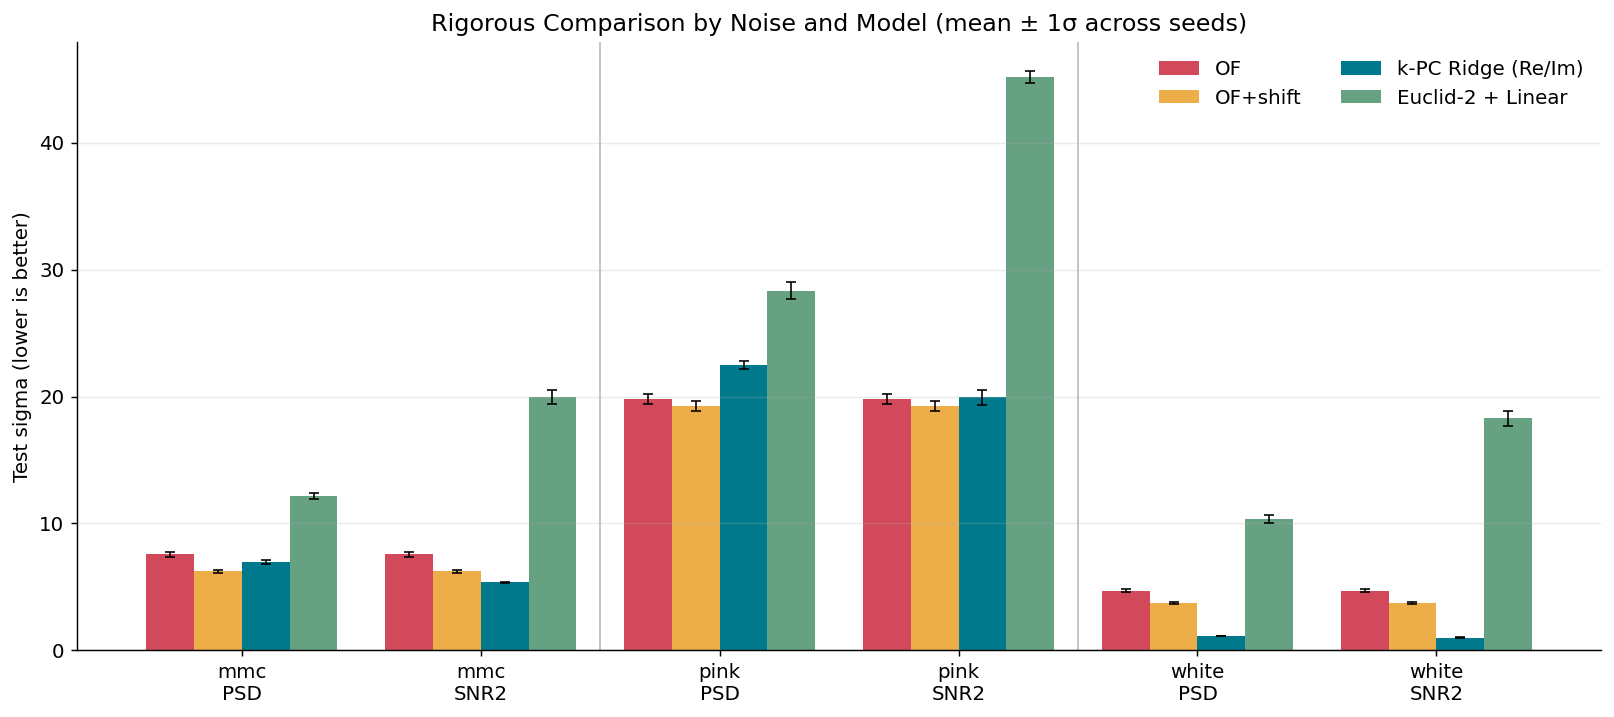

In [5]:
noise_order = ['mmc', 'pink', 'white']
model_order = ['PSD', 'SNR2']
group_keys = [(n, m) for n in noise_order for m in model_order]

x = np.arange(len(group_keys))
width = 0.2

fig, ax = plt.subplots(figsize=(12.3, 5.4), constrained_layout=True)

for i, method in enumerate(METHOD_ORDER):
    vals = []
    errs = []
    for n, m in group_keys:
        q = df_methods[(df_methods['noise_type'] == n) & (df_methods['weight_type'] == m) & (df_methods['method'] == method)]
        if len(q):
            vals.append(float(q['sigma_mean'].iloc[0]))
            errs.append(float(q['sigma_std'].iloc[0]))
        else:
            vals.append(np.nan)
            errs.append(0.0)

    offset = (i - (len(METHOD_ORDER) - 1) / 2) * width
    ax.bar(
        x + offset,
        vals,
        width=width,
        yerr=errs,
        capsize=3,
        label=method,
        color=COLORS[method],
        error_kw={'elinewidth': 1.0, 'alpha': 0.9},
    )

for boundary in [1.5, 3.5]:
    ax.axvline(boundary, color='0.75', linewidth=1.0)

ax.set_xticks(x)
ax.set_xticklabels([f'{n}\n{m}' for n, m in group_keys])
ax.set_ylabel('Test sigma (lower is better)')
ax.set_title('Rigorous Comparison by Noise and Model (mean ± 1σ across seeds)')
ax.grid(axis='y', alpha=0.25)
ax.legend(frameon=False, ncol=2)

fig.savefig(FIG_DIR / 'rigorous_bar_by_noise_model_methods.png', dpi=300)
plt.show()


## Plot 2: Test Sigma vs k (REIM, alpha tuned on val, mean ± 1σ)


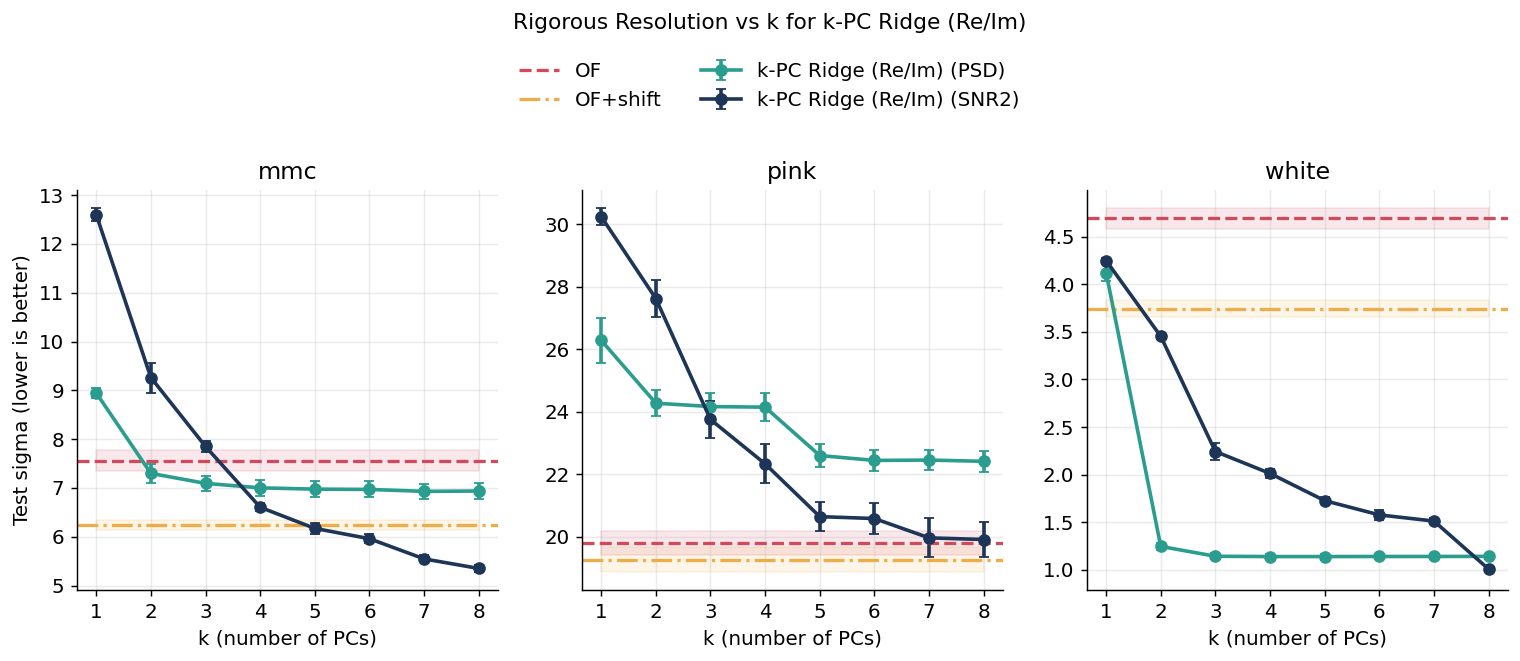

In [6]:
k_vals = sorted(df_kcurve['k'].unique())

fig, axes = plt.subplots(1, 3, figsize=(14.2, 4.0), sharey=False)
for ax, noise in zip(axes, ['mmc', 'pink', 'white']):
    for wlabel in ['PSD', 'SNR2']:
        d = df_kcurve[(df_kcurve['noise_type'] == noise) & (df_kcurve['weight_type'] == wlabel)].sort_values('k')
        if len(d) == 0:
            continue
        ax.errorbar(
            d['k'],
            d['sigma_mean'],
            yerr=d['sigma_std'],
            marker='o',
            linewidth=2.0,
            capsize=3,
            color=COLORS[wlabel],
            label=f'{METHOD_REIM} ({wlabel})',
        )

    q_of = df_methods[(df_methods['noise_type'] == noise) & (df_methods['method'] == METHOD_OF)]
    q_ofs = df_methods[(df_methods['noise_type'] == noise) & (df_methods['method'] == METHOD_OF_SHIFT)]

    if len(q_of):
        m = float(q_of['sigma_mean'].iloc[0])
        s = float(q_of['sigma_std'].iloc[0])
        ax.axhline(m, color=COLORS[METHOD_OF], linestyle='--', linewidth=1.8, label=METHOD_OF)
        ax.fill_between([min(k_vals), max(k_vals)], m - s, m + s, color=COLORS[METHOD_OF], alpha=0.12)

    if len(q_ofs):
        m = float(q_ofs['sigma_mean'].iloc[0])
        s = float(q_ofs['sigma_std'].iloc[0])
        ax.axhline(m, color=COLORS[METHOD_OF_SHIFT], linestyle='-.', linewidth=1.8, label=METHOD_OF_SHIFT)
        ax.fill_between([min(k_vals), max(k_vals)], m - s, m + s, color=COLORS[METHOD_OF_SHIFT], alpha=0.12)

    ax.set_title(noise)
    ax.set_xlabel('k (number of PCs)')
    ax.set_xticks(k_vals)
    ax.grid(alpha=0.25)

axes[0].set_ylabel('Test sigma (lower is better)')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=2, loc='upper center', frameon=False, bbox_to_anchor=(0.5, 1.16))
fig.suptitle('Rigorous Resolution vs k for k-PC Ridge (Re/Im)', y=1.22, fontsize=12)

fig.savefig(FIG_DIR / 'rigorous_sigma_vs_k_reim.png', dpi=300)
plt.show()


## Plot 3: Diagnostic Parity + Residuals (Best REIM group, one representative seed)


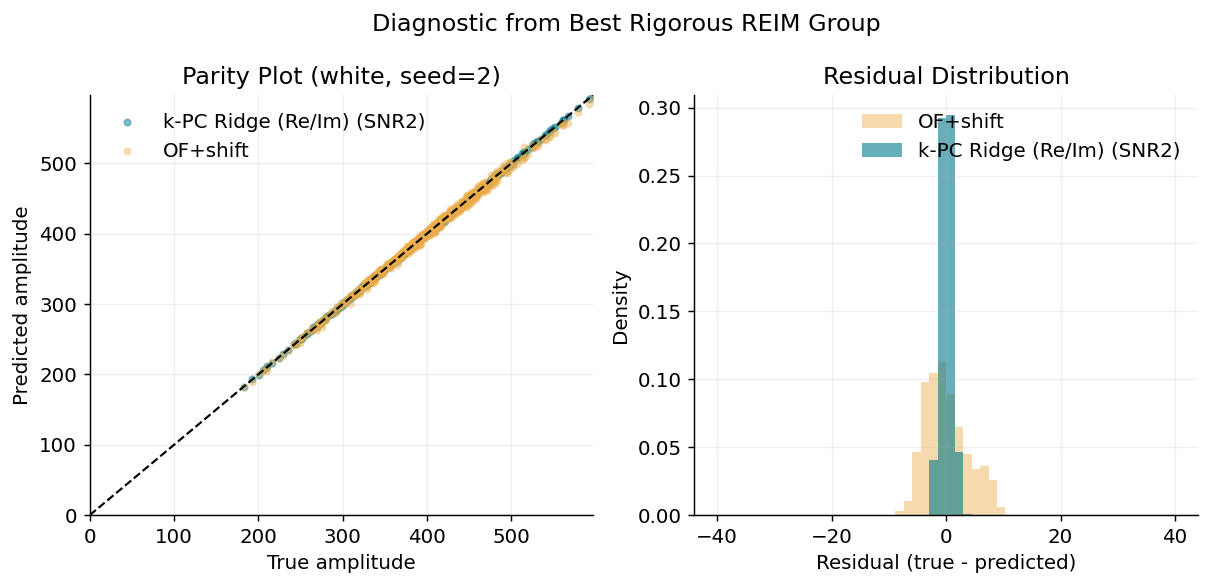

diagnostic selection: {'noise_type': 'white', 'weight_type': 'SNR2', 'seed': 2, 'sigma_mean': 1.0061039556062041, 'sigma_std': 0.029629881538544907}


In [7]:
df_reim_summary = df_methods[df_methods['method'] == METHOD_REIM].copy()
if len(df_reim_summary) == 0:
    print('No REIM summary rows available for diagnostic plot.')
else:
    best_group = df_reim_summary.sort_values('sigma_mean').iloc[0]
    noise = best_group['noise_type']
    wlabel = best_group['weight_type']

    # representative seed: best test sigma within the best group
    cands = df_methods_seed[
        (df_methods_seed['noise_type'] == noise)
        & (df_methods_seed['weight_type'] == wlabel)
        & (df_methods_seed['method'] == METHOD_REIM)
    ].sort_values('sigma')

    if len(cands) == 0:
        raise RuntimeError(f'No seed-level REIM rows for {(noise, wlabel)}')

    seed = int(cands.iloc[0]['seed'])

    key_rr = (noise, wlabel, METHOD_REIM, seed)
    if key_rr not in pred_store:
        raise RuntimeError(f'Missing prediction cache for {key_rr}')

    y_true = pred_store[key_rr]['y_true']
    y_pred_rr = pred_store[key_rr]['y_est']

    if (noise, METHOD_OF_SHIFT, seed) in pred_store:
        of_label = METHOD_OF_SHIFT
        y_pred_of = pred_store[(noise, METHOD_OF_SHIFT, seed)]['y_est']
    elif (noise, METHOD_OF, seed) in pred_store:
        of_label = METHOD_OF
        y_pred_of = pred_store[(noise, METHOD_OF, seed)]['y_est']
    else:
        of_label = None
        y_pred_of = None

    res_rr = y_true - y_pred_rr

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

    axes[0].scatter(y_true, y_pred_rr, s=12, alpha=0.45, color=COLORS[METHOD_REIM], label=f'{METHOD_REIM} ({wlabel})')
    if y_pred_of is not None:
        axes[0].scatter(y_true, y_pred_of, s=12, alpha=0.35, color=COLORS[of_label], label=of_label)

    lims = [0, max(float(np.max(y_true)), float(np.max(y_pred_rr)), float(np.max(y_pred_of)) if y_pred_of is not None else 0.0)]
    axes[0].plot(lims, lims, 'k--', linewidth=1.2)
    axes[0].set_xlim(lims)
    axes[0].set_ylim(lims)
    axes[0].set_xlabel('True amplitude')
    axes[0].set_ylabel('Predicted amplitude')
    axes[0].set_title(f'Parity Plot ({noise}, seed={seed})')
    axes[0].legend(frameon=False)
    axes[0].grid(alpha=0.2)

    bins = np.linspace(-40, 40, 55)
    if y_pred_of is not None:
        res_of = y_true - y_pred_of
        axes[1].hist(res_of, bins=bins, alpha=0.45, color=COLORS[of_label], label=of_label, density=True)
    axes[1].hist(res_rr, bins=bins, alpha=0.60, color=COLORS[METHOD_REIM], label=f'{METHOD_REIM} ({wlabel})', density=True)
    axes[1].set_xlabel('Residual (true - predicted)')
    axes[1].set_ylabel('Density')
    axes[1].set_title('Residual Distribution')
    axes[1].legend(frameon=False)
    axes[1].grid(alpha=0.2)

    fig.suptitle('Diagnostic from Best Rigorous REIM Group', y=1.03)
    fig.savefig(FIG_DIR / 'rigorous_diagnostic_parity_residual.png', dpi=300)
    plt.show()

    print('diagnostic selection:', {
        'noise_type': noise,
        'weight_type': wlabel,
        'seed': seed,
        'sigma_mean': float(best_group['sigma_mean']),
        'sigma_std': float(best_group['sigma_std']),
    })


## Table Export (Markdown / LaTeX, mean ± 1σ across seeds)


In [8]:
table_mean = (
    df_methods
    .pivot_table(index=['noise_type', 'weight_type'], columns='method', values='sigma_mean', aggfunc='first')
    .reset_index()
)
table_std = (
    df_methods
    .pivot_table(index=['noise_type', 'weight_type'], columns='method', values='sigma_std', aggfunc='first')
    .reset_index()
)

for m in METHOD_ORDER:
    if m not in table_mean.columns:
        table_mean[m] = np.nan
    if m not in table_std.columns:
        table_std[m] = np.nan

# percentage improvements from mean sigma values
table_mean['OF_to_OFshift_pct'] = 100.0 * (table_mean[METHOD_OF] - table_mean[METHOD_OF_SHIFT]) / table_mean[METHOD_OF]
table_mean['OF_to_REIM_pct'] = 100.0 * (table_mean[METHOD_OF] - table_mean[METHOD_REIM]) / table_mean[METHOD_OF]
table_mean['OF_to_Euclid2_pct'] = 100.0 * (table_mean[METHOD_OF] - table_mean[METHOD_EUCLID2]) / table_mean[METHOD_OF]

order = [
    'noise_type', 'weight_type',
    METHOD_OF, METHOD_OF_SHIFT, METHOD_REIM, METHOD_EUCLID2,
    'OF_to_OFshift_pct', 'OF_to_REIM_pct', 'OF_to_Euclid2_pct',
]
table_mean = table_mean[order].sort_values(['noise_type', 'weight_type'])

# formatted display: mean ± std for method columns
table_disp = table_mean[['noise_type', 'weight_type']].copy()
for m in METHOD_ORDER:
    m_mean = table_mean[m].to_numpy(dtype=float)
    m_std = table_std[m].to_numpy(dtype=float)
    table_disp[m] = [f'{a:.3f} ± {b:.3f}' if np.isfinite(a) else 'nan' for a, b in zip(m_mean, m_std)]

for c in ['OF_to_OFshift_pct', 'OF_to_REIM_pct', 'OF_to_Euclid2_pct']:
    table_disp[c] = table_mean[c].map(lambda x: f'{x:.2f}' if pd.notna(x) else 'nan')

display(table_disp)

print('Markdown table:')
print(table_disp.to_markdown(index=False))
print()
print('LaTeX table:')
print(table_disp.to_latex(index=False, escape=False))

csv_mean_path = FIG_DIR / 'rigorous_metrics_table_mean.csv'
csv_seed_path = FIG_DIR / 'rigorous_metrics_seed_level.csv'
table_mean.to_csv(csv_mean_path, index=False)
df_methods_seed.to_csv(csv_seed_path, index=False)
print('saved csv:', csv_mean_path)
print('saved csv:', csv_seed_path)


method,noise_type,weight_type,OF,OF+shift,k-PC Ridge (Re/Im),Euclid-2 + Linear,OF_to_OFshift_pct,OF_to_REIM_pct,OF_to_Euclid2_pct
0,mmc,PSD,7.561 ± 0.220,6.239 ± 0.109,6.954 ± 0.156,12.167 ± 0.228,17.49,8.03,-60.91
1,mmc,SNR2,7.561 ± 0.220,6.239 ± 0.109,5.350 ± 0.071,19.982 ± 0.572,17.49,29.24,-164.26
2,pink,PSD,19.802 ± 0.372,19.265 ± 0.393,22.470 ± 0.295,28.327 ± 0.669,2.71,-13.48,-43.06
3,pink,SNR2,19.802 ± 0.372,19.265 ± 0.393,19.928 ± 0.571,45.189 ± 0.493,2.71,-0.64,-128.21
4,white,PSD,4.693 ± 0.110,3.744 ± 0.092,1.140 ± 0.031,10.321 ± 0.317,20.22,75.72,-119.90
5,white,SNR2,4.693 ± 0.110,3.744 ± 0.092,1.006 ± 0.030,18.297 ± 0.587,20.22,78.56,-289.84


Markdown table:
| noise_type   | weight_type   | OF             | OF+shift       | k-PC Ridge (Re/Im)   | Euclid-2 + Linear   |   OF_to_OFshift_pct |   OF_to_REIM_pct |   OF_to_Euclid2_pct |
|:-------------|:--------------|:---------------|:---------------|:---------------------|:--------------------|--------------------:|-----------------:|--------------------:|
| mmc          | PSD           | 7.561 ± 0.220  | 6.239 ± 0.109  | 6.954 ± 0.156        | 12.167 ± 0.228      |               17.49 |             8.03 |              -60.91 |
| mmc          | SNR2          | 7.561 ± 0.220  | 6.239 ± 0.109  | 5.350 ± 0.071        | 19.982 ± 0.572      |               17.49 |            29.24 |             -164.26 |
| pink         | PSD           | 19.802 ± 0.372 | 19.265 ± 0.393 | 22.470 ± 0.295       | 28.327 ± 0.669      |                2.71 |           -13.48 |              -43.06 |
| pink         | SNR2          | 19.802 ± 0.372 | 19.265 ± 0.393 | 19.928 ± 0.571       | 45.189 ± 0.493     